In [1]:
import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('../datasets/sp500_index.csv')

In [3]:
data

,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57
...,...,...
2512,2024-12-16,6074.08
2513,2024-12-17,6050.61
2514,2024-12-18,5872.16
2515,2024-12-19,5867.08


In [4]:
returns = np.log((data['S&P500'].shift(-1)) / data['S&P500'])

In [5]:
data['S&P500'].shift(-1)

0       2082.17
1       2081.88
2       2088.77
3       2090.57
4       2080.35
         ...   
2512    6050.61
2513    5872.16
2514    5867.08
2515    5930.85
2516        NaN
Name: S&P500, Length: 2517, dtype: float64

In [6]:
data['S&P500']

0       2078.54
1       2082.17
2       2081.88
3       2088.77
4       2090.57
         ...   
2512    6074.08
2513    6050.61
2514    5872.16
2515    5867.08
2516    5930.85
Name: S&P500, Length: 2517, dtype: float64

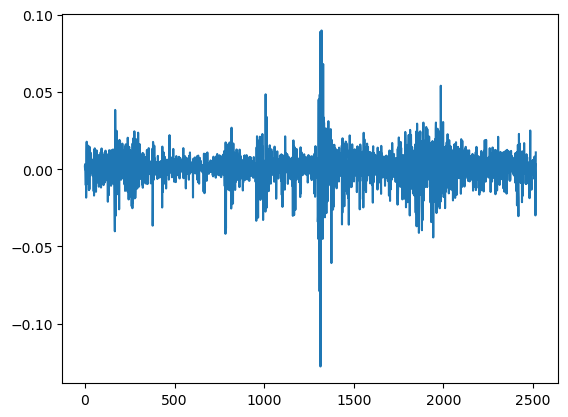

In [7]:
plt.plot(returns)

In [8]:
data_obs = np.array(returns).reshape(1, -1)[:, -1000:-1]

In [9]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [0.002, 0.01],  # state 0
    [-0.02, 0.01],  # state 1
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=150, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

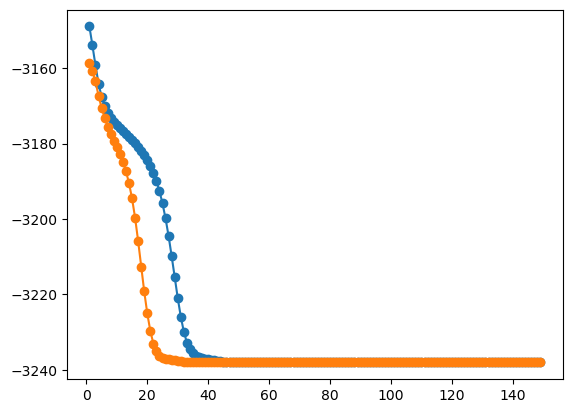

In [10]:
import matplotlib.pyplot as plt

for i in range(2):
    
    plt.plot(range(1, np.array(err).shape[1]-1), -np.array(err)[i, 2:], marker='o')

In [11]:
print(HMM_list[-1].emission.gauss_params)


[[ 0.00112496  0.00693644]
 [-0.00056735  0.01410366]]


In [12]:
HMM.emission.gauss_params

array([[ 0.00112496,  0.00693644],
       [-0.00056735,  0.01410366]])

In [13]:
HMM.Viterbi(data_obs)

In [14]:
print(HMM.best_seqs.shape)

(1, 999)


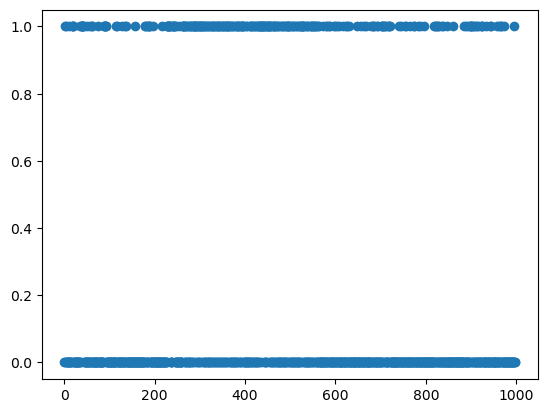

In [16]:
plt.plot(HMM.best_seqs[0, :], marker='o', linestyle = '')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimes(dates,prices, hidden_states, n_states):
    
    colors = ['green', 'red']  # un colore per stato
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(dates, prices, color='black', linewidth=2, zorder=2)
    
    # colora le regioni
    i = 0
    while i < len(hidden_states):
        state = int(hidden_states[i])
        j = i
        # trova fino a dove dura questo regime
        while j < len(hidden_states) and hidden_states[j] == state:
            j += 1
        ax.axvspan(dates[i], dates[min(j, len(dates)-1)], 
                   alpha=0.3, color=colors[state], zorder=1)
        i = j
    
    # legenda manuale
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors[k], alpha=0.3, label=f'Regime {k}') 
              for k in range(n_states)]
    ax.legend(handles=legend, loc='upper left')
    
    ax.set_xlabel('time')
    ax.set_ylabel('return')
    plt.tight_layout()
    plt.show()

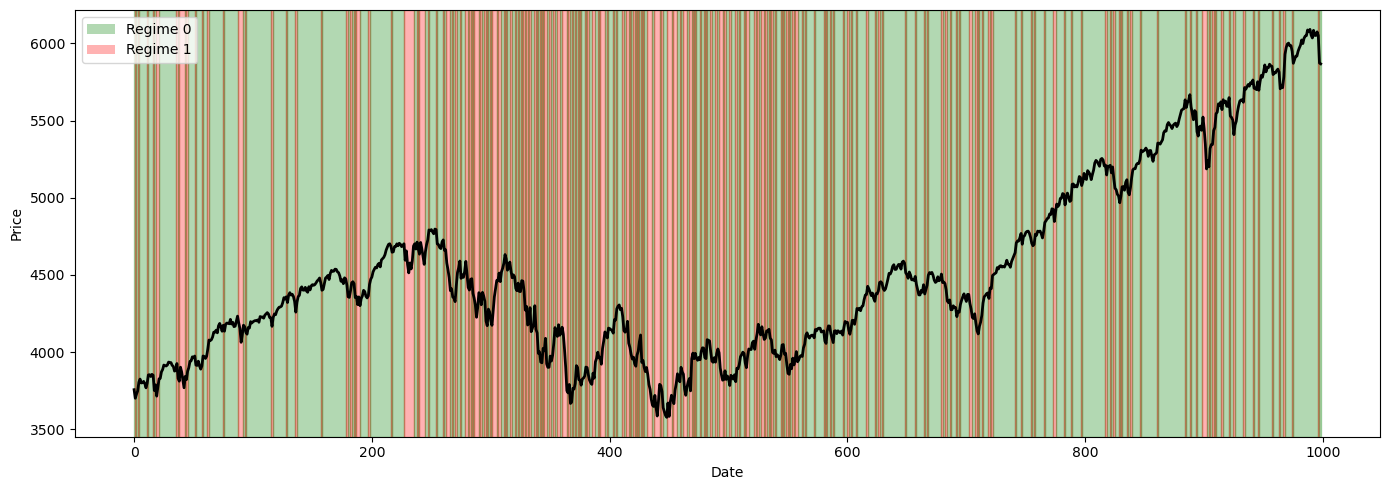

In [38]:
dates = [i for i in range(999)]

plot_regimes(dates[:], np.array(data['S&P500'])[-1000:-1], HMM.best_seqs[0, :] , n_states=2)